#### Bar mapping experiment for pRF

First load necessary libraries and initialize pgl

In [ ]:
# autoload
%load_ext autoreload
%autoreload 2

# import necessary libraries
import numpy as np

# Load PGL libraries and start a PGL window
from pgl import pgl, pglExperiment, pglFixationTaskLeftRight, pglBarTask
pgl = pgl()

# close any existing windows
pgl.cleanUp()

##### Display setting

In [ ]:
pgl.settings()

##### Setup the experiment and run

(pglSettingsManager:loadSettings) Loading settings from '/Users/gru/.pgl/settings/CNI_projector.json'.
(pglSettingsEditable:init) Loading settings from '/Users/gru/.pgl/settings/CNI_projector.json'.
================================= pglBase:open =================================
(pglBase:open) Starting mglMetal application: /Users/gru/proj/pgl/metal/mglMetal.app
(pglBase:open) Using socket with address: /Users/gru/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260327_155616.D8dTz5qSFp
(pgl:_pglComm) .Connected to: /Users/gru/Library/Containers/gru.mglMetal/Data/pglMetal.socket.20260327_155616.D8dTz5qSFp
(pgl:_resolution:getResolution) Display 1/2: 1920x1080 60Hz 32bits
(pglKeyboardMouse:start) Starting keyboard and mouse event listener.
(pglEventListener) Eating 11 keys: [18, 19, 20, 21, 22, 23, 25, 26, 28, 49, 53]
(pglBarTask) Total expected task time: 1 minutes 36.0 seconds, 96 volumes  (8 directions, 12.0 seconds/sweep, 12 volumes/sweep)
(pglExperiment:run) Manual pre-start 

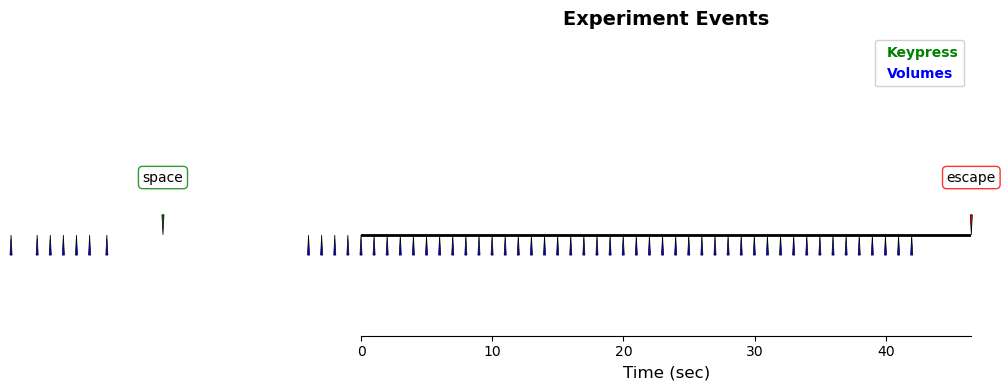

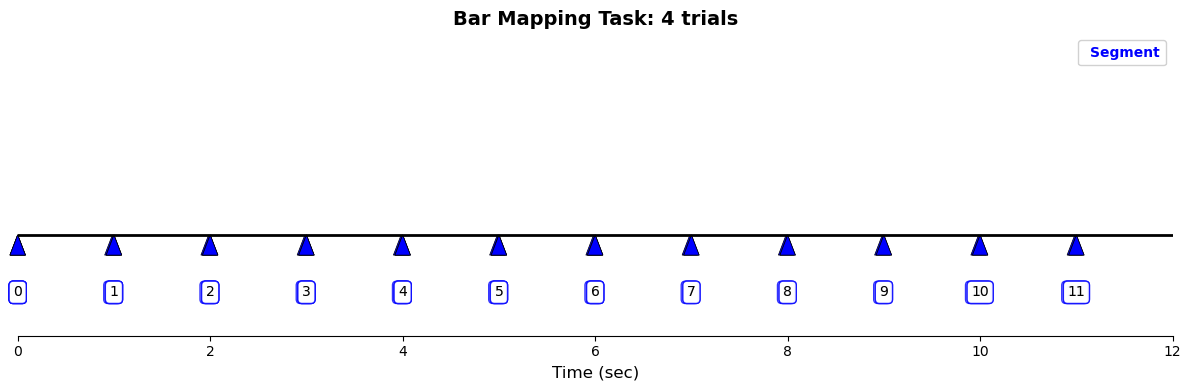

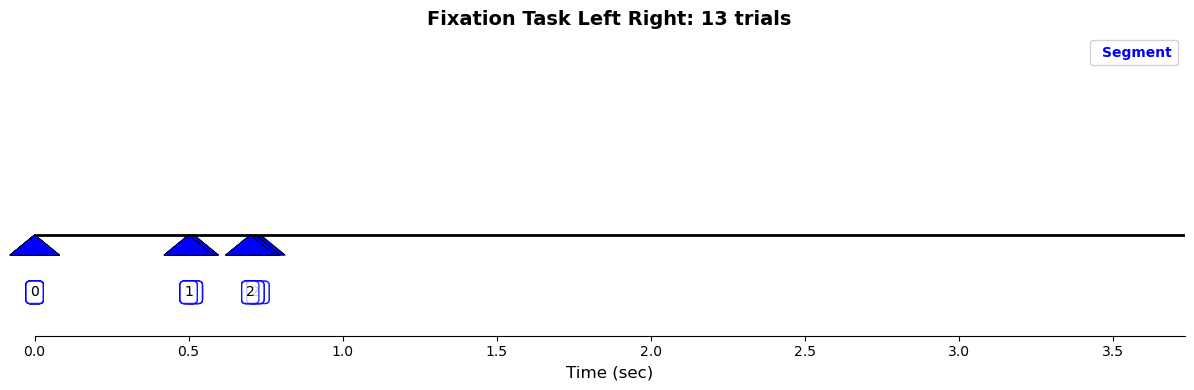

In [7]:
# Set up experiment
e = pglExperiment(pgl, "CNI_projector", experimentName="pglBarTask")
e.initScreen()

# initialize tasks
fixationTask = pglFixationTaskLeftRight(pgl)
barTask = pglBarTask(pgl, sweepWidth=25, sweepHeight=25)

# add the tasks to the experiment
e.addTask(barTask)
e.addTask(fixationTask)

# and run the experiment
e.run()

# display results
e.display()

##### Load experiment

In [ ]:
e = pglExperiment(experimentName="pglBarTask")

##### Get stimulus images

In [ ]:
# hacked for now = grab task settings and create a pglBarTask with the same settings
t = next((task for task in e.tasks if task.settings.taskName == "Bar Mapping Task"), None)
barTask = pglBarTask(pgl)
barTask.settings = t.settings
barTask.data = t.data
barTask.state = t.state
print(barTask.settings.taskName)
frames = barTask.getStimulusFrames(pgl, e.data.events, e.settings)

##### Display stimulus images

In [ ]:
# display stimulus frames as a movie
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np

def showFramesJupyter(frames):
    """
    frames: numpy array with shape (numFrames, height, width, 4) - RGBA
    """
    
    numFrames = frames.shape[0]
    
    # Create output widget
    outputWidget = widgets.Output()
    
    # Create slider
    frameSlider = widgets.IntSlider(
        value=0,
        min=0,
        max=numFrames-1,
        description='Frame:',
        continuous_update=True,
        layout=widgets.Layout(width='400px')
    )
    
    # Create play button
    playButton = widgets.Play(
        value=0,
        min=0,
        max=numFrames-1,
        step=1,
        interval=100,
        description="Press play"
    )
    
    # Create increment/decrement buttons
    prevButton = widgets.Button(
        description='◀ Prev',
        button_style='',
        tooltip='Previous frame',
        icon='arrow-left'
    )
    
    nextButton = widgets.Button(
        description='Next ▶',
        button_style='',
        tooltip='Next frame',
        icon='arrow-right'
    )
    
    # Button click handlers
    def onPrevClick(b):
        if frameSlider.value > 0:
            frameSlider.value -= 1
    
    def onNextClick(b):
        if frameSlider.value < numFrames - 1:
            frameSlider.value += 1
    
    prevButton.on_click(onPrevClick)
    nextButton.on_click(onNextClick)
    
    # Link play button to slider
    widgets.jslink((playButton, 'value'), (frameSlider, 'value'))
    
    # Update function
    def updateFrame(change):
        with outputWidget:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(10, 7.5))
            ax.imshow(frames[change['new']])
            ax.set_title(f"Frame {change['new']} / {numFrames-1}")
            ax.axis('off')
            plt.tight_layout()
            plt.show()
            plt.close(fig)
    
    # Attach observer
    frameSlider.observe(updateFrame, names='value')
    
    # Layout widgets
    buttonBox = widgets.HBox([playButton, prevButton, nextButton])
    controlBox = widgets.VBox([buttonBox, frameSlider])
    
    display(controlBox)
    display(outputWidget)
    
    # Show first frame
    updateFrame({'new': 0})

# Usage
showFramesJupyter(frames)


##### Format and save to matlab

In [ ]:
# format and save to .mat file (pRFStimImage.mat on Desktop)
import scipy.io
import numpy as np
import os

# Create copy and apply transformations
stimImage = frames.copy()

# Keep only first channel (R, drop GBA)
stimImage = stimImage[:, :, :, 0]

# Map values: 0.5 -> 0, everything else -> 1
stimImage = np.where(stimImage == 0.5, 0, 1)

# Flip left-right (horizontal flip)
stimImage = np.flip(stimImage, axis=2) 

# filepath
filepath = os.path.join(os.path.expanduser('~/Desktop'), 'pRFStimImage.mat')

# Save your frames array
scipy.io.savemat(filepath, { 'stimImage': stimImage })